In [116]:
#importing libaries
import joblib
import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [117]:
#importing dataset
data = pd.read_csv('project4_waste_generation.csv')

In [118]:
#Displaying first five rows
data.head()

,Week_Start_Date,Neighborhood,Population_Density_per_km2,Number_of_Businesses,Avg_Household_Size,Market_Present,Industrial_Zone,Collection_Frequency_per_Week,Month,Weekly_Waste_Weight_kg
0,2020-01-06,Bambili,4432,432,8.3,0,0,1,1,2736.7
1,2020-01-13,Bambili,4403,428,8.4,0,0,1,1,2407.3
2,2020-01-20,Bambili,4360,427,8.3,0,0,1,1,2346.0
3,2020-01-27,Bambili,4373,433,8.4,0,0,1,1,2831.3
4,2020-02-03,Bambili,4352,426,7.7,0,0,1,2,2688.3


In [119]:
#Analyzing the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Week_Start_Date                10000 non-null  object 
 1   Neighborhood                   10000 non-null  object 
 2   Population_Density_per_km2     10000 non-null  int64  
 3   Number_of_Businesses           10000 non-null  int64  
 4   Avg_Household_Size             10000 non-null  float64
 5   Market_Present                 10000 non-null  int64  
 6   Industrial_Zone                10000 non-null  int64  
 7   Collection_Frequency_per_Week  10000 non-null  int64  
 8   Month                          10000 non-null  int64  
 9   Weekly_Waste_Weight_kg         10000 non-null  float64
dtypes: float64(2), int64(6), object(2)
memory usage: 781.4+ KB


In [120]:
#viewing data features
data.describe()

,Population_Density_per_km2,Number_of_Businesses,Avg_Household_Size,Market_Present,Industrial_Zone,Collection_Frequency_per_Week,Month,Weekly_Waste_Weight_kg
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2477.740600,282.957100,6.007350,0.600000,0.280000,1.960000,6.483300,2103.634690
std,1222.465775,174.487167,1.475059,0.489922,0.449021,0.773602,3.447537,690.010899
min,198.000000,8.000000,2.900000,0.000000,0.000000,1.000000,1.000000,736.300000
25%,1444.000000,123.000000,4.700000,0.000000,0.000000,1.000000,4.000000,1581.725000
50%,2567.000000,298.000000,6.100000,1.000000,0.000000,2.000000,7.000000,2072.700000
75%,3515.000000,426.000000,7.200000,1.000000,1.000000,3.000000,10.000000,2582.125000
max,4502.000000,569.000000,9.100000,1.000000,1.000000,3.000000,12.000000,4603.700000


In [121]:
#Checking for Null Values
data.isnull().sum()

Week_Start_Date                  0
Neighborhood                     0
Population_Density_per_km2       0
Number_of_Businesses             0
Avg_Household_Size               0
Market_Present                   0
Industrial_Zone                  0
Collection_Frequency_per_Week    0
Month                            0
Weekly_Waste_Weight_kg           0
dtype: int64

In [122]:
#Spliting data to remove target column values for efficient training 
features = data.drop((['Weekly_Waste_Weight_kg', 'Week_Start_Date', 'Neighborhood']), axis=1)
target = data['Weekly_Waste_Weight_kg']

In [123]:
#Separating our data into training and testing datasets
features_train, features_test, target_train, target_test = train_test_split(features,target, test_size= 0.2, random_state=42)

In [124]:
#training our model
model = LinearRegression()
model.fit (features_train, target_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [125]:
model_prediction = model.predict(features_test)
# features_test contains inputs the model has NEVER seen before
# model.predict() tells the model: "guess the waste volume for each row"
# model_predict is now a list of the model's guesses

In [126]:
# mean_squared_error  → calculates MSE (average of squared errors)
# mean_absolute_error → calculates MAE (average of raw errors)
# r2_score            → calculates R² (how well model learned the pattern)

mae  = mean_absolute_error(target_test, model_prediction)
# MAE: compares y_test (real answers) vs y_predict (model guesses)
# Result = average kg the model is wrong by

mse  = mean_squared_error(target_test, model_prediction)
# MSE: same as MAE but SQUARES the errors before averaging
# This punishes big mistakes more heavily than small ones

rmse = np.sqrt(mse)
# RMSE: we take the square root of MSE to bring it back to kg units
# Easier to understand than MSE because it's in the same unit as your target

r2   = r2_score(target_test, model_prediction)
# R²: tells you what % of the waste pattern your model actually learned
# R² = 1.0 means perfect, R² = 0.87 means 87% accurate

print("Model Evaluation Results")
print("-------------------------")
print(f"MAE  : {mae:.2f} kg")   # :.2f means show only 2 decimal places
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} kg")
print(f"R²   : {r2:.2f}")

Model Evaluation Results
-------------------------
MAE  : 228.11 kg
MSE  : 83428.72
RMSE : 288.84 kg
R²   : 0.83


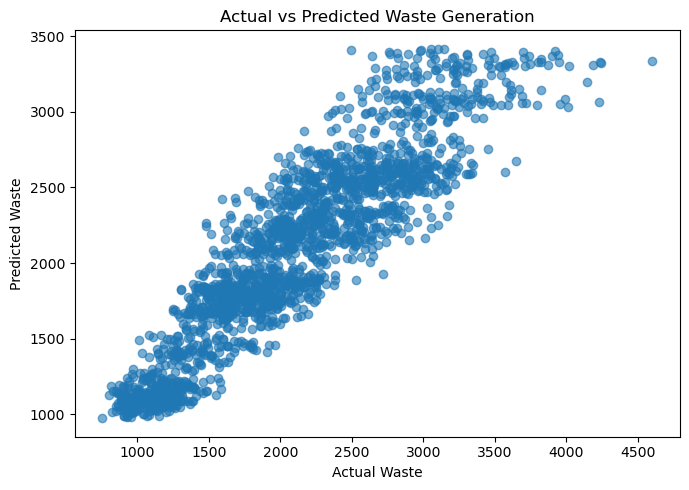

In [127]:
plt.figure(figsize=(7,5))
plt.scatter(target_test, model_prediction, alpha=0.6)#
plt.xlabel("Actual Waste")
plt.ylabel("Predicted Waste")
plt.title("Actual vs Predicted Waste Generation")

plt.plot()
[target_test.min(), target_test.max()],
[target_test.min(), target_test.max()],
'r--'
# This graph explains
# Points close to the line
# Model predicts well.
# Points far from the line
# Prediction error is large.
# Tight cluster around line
# Strong model performance.
# Scattered cloud
# Model struggles to learn patterns.
plt.tight_layout()
plt.show()

In [128]:
joblib.dump(model, 'model.joblib')

['model.joblib']

In [129]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(features_train, target_train)
forest = RandomForestRegressor(n_estimators = 100)
forest.fit(features_train, target_train)        # train the random forest 
model_pred_tree   = tree.predict(features_test)    # decision tree predictions
model_pred_forest = forest.predict(features_test)  # random forest predictions 


In [130]:
mae_tree = mean_absolute_error(target_test, model_pred_tree)
mse_tree = mean_squared_error(target_test, model_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(target_test, model_pred_tree)

print(f"Decision Tree MAE  : {mae_tree:.2f}")
print(f"Decision Tree RMSE : {rmse_tree:.2f}")
print(f"Decision Tree R²   : {r2_tree:.2f}")

Decision Tree MAE  : 214.42
Decision Tree RMSE : 279.23
Decision Tree R²   : 0.84


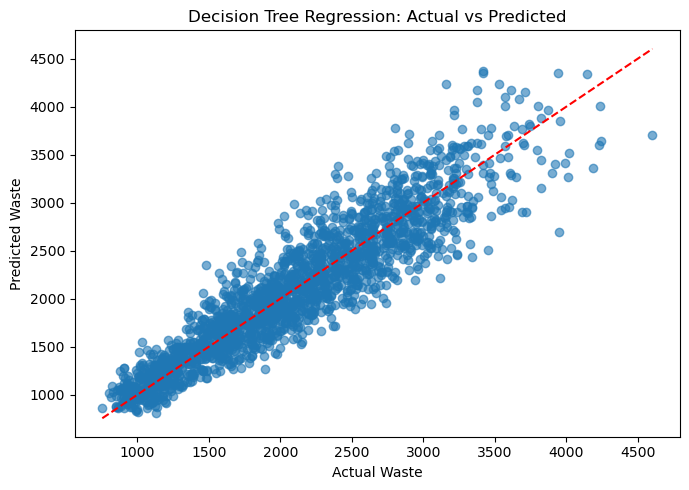

In [131]:
plt.figure(figsize=(7,5))

plt.scatter(target_test, model_pred_tree, alpha=0.6)

plt.plot(
    [target_test.min(), target_test.max()],
    [target_test.min(), target_test.max()],
    'r--'
)

plt.xlabel("Actual Waste")
plt.ylabel("Predicted Waste")
plt.title("Decision Tree Regression: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [132]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "R² Score": [r2, r2_tree],
    "RMSE": [rmse, rmse_tree],
    "MAE": [mae, mae_tree]
})

print(results)

               Model  R² Score        RMSE         MAE
0  Linear Regression  0.825785  288.840296  228.113094
1      Decision Tree  0.837185  279.229759  214.417400


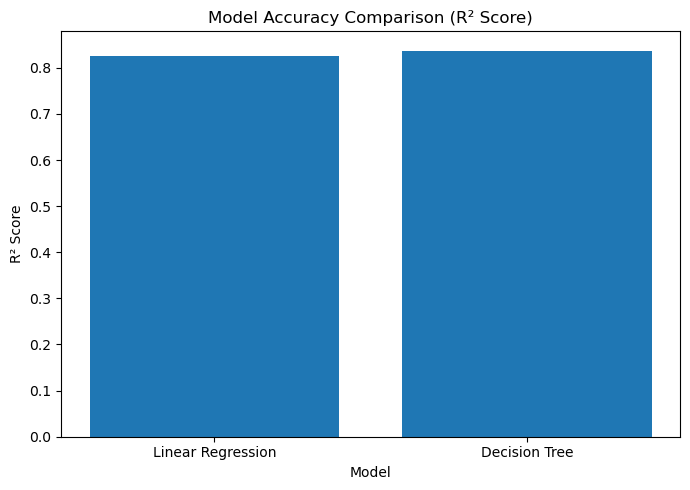

In [133]:
plt.figure(figsize=(7,5))

plt.bar(results["Model"], results["R² Score"])

plt.title("Model Accuracy Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xlabel("Model")

plt.tight_layout()
plt.show()

In [134]:
gboost_model = GradientBoostingRegressor(
    n_estimators=200,     # number of trees
    learning_rate=0.05,   # learning speed
    max_depth=3,
    random_state=42
)

In [135]:
gboost_model.fit(features_train, target_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [136]:
pred_gboost = gboost_model.predict(features_test)

In [137]:
r2_gboost = r2_score(target_test, pred_gboost)
rmse_gboost = np.sqrt(mean_squared_error(target_test, pred_gboost))
mae_gboost = mean_absolute_error(target_test, pred_gboost)

print("===== Gradient Boosting Results =====")
print(f"R² Score (Accuracy): {r2_gboost:.3f}")
print(f"RMSE: {rmse_gboost:.2f}")
print(f"MAE : {mae_gboost:.2f}")

===== Gradient Boosting Results =====
R² Score (Accuracy): 0.922
RMSE: 193.76
MAE : 148.85


In [138]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Gradient Boosting"
    ],
    "R² Score": [
        r2,
        r2_tree,
        r2_gboost
    ]
})

print(results)

               Model  R² Score
0  Linear Regression  0.825785
1      Decision Tree  0.837185
2  Gradient Boosting  0.921602


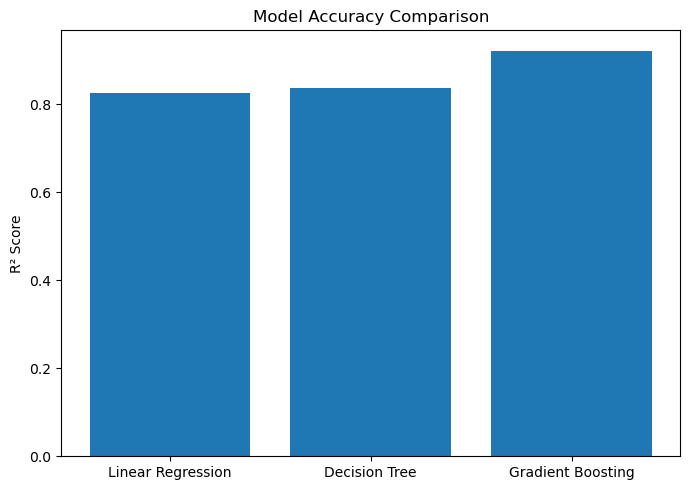

In [139]:
plt.figure(figsize=(7,5))
plt.bar(results["Model"], results["R² Score"])

plt.title("Model Accuracy Comparison")
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()

In [140]:
joblib.dump(model, 'gboost_model.joblib')

['gboost_model.joblib']

In [141]:
joblib.dump(model, 'tree.joblib')

['tree.joblib']

In [142]:
joblib.dump(model, 'forest.joblib')

['forest.joblib']